# 1.2. Hồi quy có Regularization và Lựa chọn Đặc trưng

> **Mục tiêu**: Cài đặt từ đầu Ridge Regression (L2), Lasso Regression (L1), Elastic Net (L1+L2), chọn siêu tham số λ bằng k-fold CV, vẽ regularization path, và thực hiện feature selection.

## 0. Import thư viện và load dữ liệu

In [1]:
import sys, os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.1, rc={
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

SEED = 42
np.random.seed(SEED)

# --- Load data ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from eda_preprocessing.load_data import load_regression_data

data = load_regression_data()
X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]
feature_names = data["feature_names"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")

X_train: (12165, 49), y_train: (12165,)
X_val  : (1737, 49),   y_val  : (1737,)
X_test : (3477, 49),  y_test : (3477,)
Features (49): ['temp', 'hum', 'windspeed', 'season_2', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'time_of_day_1', 'time_of_day_2', 'yr', 'workingday', 'holiday', 'is_rush_hour']


## 0.1. Hàm phụ trợ

In [2]:
def _add_bias(X):
    return np.column_stack([np.ones(X.shape[0]), X])

def _soft_threshold(rho, lam):
    """Toán tử soft-thresholding: S(rho, lam) = sign(rho) * max(|rho| - lam, 0)."""
    if rho > lam:
        return rho - lam
    elif rho < -lam:
        return rho + lam
    else:
        return 0.0

# --- Metrics ---
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot != 0 else 0.0

def compute_all_metrics(y_true, y_pred):
    return {"MSE": mse(y_true, y_pred), "RMSE": rmse(y_true, y_pred),
            "MAE": mae(y_true, y_pred), "R²": r_squared(y_true, y_pred)}

def print_metrics(metrics, model_name="Model"):
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    for name, value in metrics.items():
        print(f"  {name:>6s}: {value:.6f}")
    print(f"{'='*50}\n")

# --- k-fold split ---
def k_fold_split(n_samples, k=10, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(n_samples)
    rng.shuffle(indices)
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[:n_samples % k] += 1
    folds = []
    current = 0
    for size in fold_sizes:
        val_idx = indices[current:current + size]
        train_idx = np.concatenate([indices[:current], indices[current + size:]])
        folds.append((train_idx, val_idx))
        current += size
    return folds

---
## 1. Ridge Regression (Regularization L2)

### 1.1. Cơ sở lý thuyết

**Ridge Regression** thêm phạt chuẩn $L_2$ vào hàm mất mát OLS để kiểm soát độ phức tạp của mô hình:

$$\mathcal{L}_{\text{Ridge}}(\mathbf{w}) = \frac{1}{2N} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \frac{\lambda}{2} \|\mathbf{w}\|_2^2$$

trong đó $\lambda > 0$ là hệ số regularization, $\|\mathbf{w}\|_2^2 = \sum_{j=1}^D w_j^2$ (hệ số bias $w_0$ **không** bị phạt).

Lấy đạo hàm và cho bằng 0:

$$\nabla_\mathbf{w} \mathcal{L} = -\frac{1}{N} \mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w}) + \lambda \mathbf{w} = 0$$

$$\boxed{\mathbf{w}^*_{\text{Ridge}} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I}')^{-1} \mathbf{X}^T \mathbf{y}}$$

trong đó $\mathbf{I}'$ là ma trận đơn vị với $I'_{00} = 0$ (không phạt bias).

> **Tính chất**: Ridge co (shrink) tất cả hệ số về phía 0 nhưng **không** bao giờ cho hệ số bằng 0 chính xác → không thực hiện feature selection.

### 1.2. Cài đặt class `RidgeRegression`

In [3]:
class RidgeRegression:
    """Ridge Regression (L2 regularization) — closed-form.
    
    Minimises: (1/2n) ||y - Xw||^2 + (lambda/2) ||w||^2
    Closed-form: w = (X^T X + lambda I')^{-1} X^T y
    """
    
    def __init__(self, lam=1.0):
        self.lam = lam
        self.w = None
        self.fit_time = 0.0
    
    def fit(self, X, y, **kwargs):
        t0 = time.perf_counter()
        X_b = _add_bias(X)
        n_samples, n_features = X_b.shape
        
        # I' — không phạt bias (phần tử [0,0] = 0)
        reg_matrix = self.lam * np.eye(n_features)
        reg_matrix[0, 0] = 0
        
        XtX = X_b.T @ X_b
        Xty = X_b.T @ y
        self.w = np.linalg.solve(XtX + reg_matrix, Xty)
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        return _add_bias(X) @ self.w
    
    @property
    def coefficients(self):
        return self.w[1:] if self.w is not None else np.array([])
    
    @property
    def intercept(self):
        return float(self.w[0]) if self.w is not None else 0.0

### 1.3. Huấn luyện và đánh giá Ridge

In [4]:
ridge_model = RidgeRegression(lam=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
metrics_ridge = compute_all_metrics(y_test, y_pred_ridge)
print_metrics(metrics_ridge, "Ridge Regression (lambda=1.0) — Test Set")
print(f"Thời gian huấn luyện: {ridge_model.fit_time:.6f} giây")


  Ridge Regression (lambda=1.0) — Test Set
     MSE: 0.348631
    RMSE: 0.590450
     MAE: 0.447178
      R²: 0.825473

Thời gian huấn luyện: 0.113633 giây


### 1.4. Phân tích kết quả Ridge

*(Cell phân tích — sẽ được cập nhật sau khi chạy)*

Kết quả Ridge với $\lambda = 1.0$ cho thấy hiệu năng tương đương hoặc gần với OLS khi mức regularization vừa phải. Hệ số bị co nhỏ so với OLS nhưng không triệt tiêu hoàn toàn, đúng với lý thuyết.

---
## 2. Lasso Regression (Regularization L1)

### 2.1. Cơ sở lý thuyết

**Lasso Regression** sử dụng phạt chuẩn $L_1$:

$$\mathcal{L}_{\text{Lasso}}(\mathbf{w}) = \frac{1}{2N} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \lambda \|\mathbf{w}\|_1$$

trong đó $\|\mathbf{w}\|_1 = \sum_{j=1}^D |w_j|$.

Do $|w_j|$ không khả vi tại $w_j = 0$, ta **không** thể tìm nghiệm dạng đóng. Thay vào đó sử dụng **Coordinate Descent**:

**Thuật toán Coordinate Descent**: Tại mỗi bước, cập nhật **một hệ số** $w_j$ trong khi giữ cố định các hệ số khác.

Với partial residual $r_j = \mathbf{y} - \mathbf{X}\mathbf{w} + X_j w_j$ và $\rho_j = \frac{1}{N} X_j^T r_j$, $z_j = \frac{1}{N} \|X_j\|^2$:

$$w_j \leftarrow \frac{S(\rho_j, \lambda)}{z_j}$$

trong đó $S$ là toán tử **soft-thresholding**:

$$\boxed{S(\rho, \lambda) = \text{sign}(\rho) \cdot \max(|\rho| - \lambda, 0) = \begin{cases} \rho - \lambda & \text{nếu } \rho > \lambda \\ \rho + \lambda & \text{nếu } \rho < -\lambda \\ 0 & \text{nếu } |\rho| \leq \lambda \end{cases}}$$

> **Tính chất quan trọng**: Soft-thresholding có thể đặt hệ số $w_j = 0$ chính xác khi $|\rho_j| \leq \lambda$ → Lasso thực hiện **feature selection tự động** (sparse solution).

### 2.2. Cài đặt class `LassoRegression`

In [5]:
class LassoRegression:
    """Lasso Regression (L1) via Coordinate Descent.
    
    Minimises: (1/2n) ||y - Xw||^2 + lambda ||w||_1
    """
    
    def __init__(self, lam=1.0, max_iter=1000, tol=1e-6):
        self.lam = lam
        self.max_iter = max_iter
        self.tol = tol
        self.w = None
        self.n_iter = 0
        self.fit_time = 0.0
    
    def fit(self, X, y, warm_start_w=None, **kwargs):
        t0 = time.perf_counter()
        X_b = _add_bias(X)
        n, p = X_b.shape
        
        if warm_start_w is not None:
            self.w = warm_start_w.copy()
        else:
            self.w = np.zeros(p)
        
        for iteration in range(self.max_iter):
            w_old = self.w.copy()
            
            for j in range(p):
                # Partial residual (loại bỏ ảnh hưởng feature j)
                residual = y - X_b @ self.w + X_b[:, j] * self.w[j]
                rho = X_b[:, j] @ residual / n
                
                if j == 0:
                    # Không phạt bias
                    self.w[j] = rho
                else:
                    z = np.sum(X_b[:, j] ** 2) / n
                    self.w[j] = _soft_threshold(rho, self.lam) / z
            
            # Kiểm tra hội tụ
            if np.max(np.abs(self.w - w_old)) < self.tol:
                self.n_iter = iteration + 1
                break
        else:
            self.n_iter = self.max_iter
        
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        return _add_bias(X) @ self.w
    
    @property
    def coefficients(self):
        return self.w[1:] if self.w is not None else np.array([])
    
    @property
    def intercept(self):
        return float(self.w[0]) if self.w is not None else 0.0
    
    @property
    def n_nonzero_coefs(self):
        return int(np.sum(np.abs(self.coefficients) > 1e-10))

### 2.3. Huấn luyện và đánh giá Lasso

In [6]:
lasso_model = LassoRegression(lam=0.01, max_iter=2000)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
metrics_lasso = compute_all_metrics(y_test, y_pred_lasso)
print_metrics(metrics_lasso, "Lasso Regression (lambda=0.01) — Test Set")
print(f"Số iteration hội tụ: {lasso_model.n_iter}")
print(f"Hệ số khác 0: {lasso_model.n_nonzero_coefs} / {len(lasso_model.coefficients)}")
print(f"Thời gian: {lasso_model.fit_time:.4f}s")


  Lasso Regression (lambda=0.01) — Test Set
     MSE: 0.413482
    RMSE: 0.643026
     MAE: 0.497357
      R²: 0.793008

Số iteration hội tụ: 93
Hệ số khác 0: 26 / 49
Thời gian: 1.1828s


### 2.4. Phân tích kết quả Lasso

Lasso thường loại bỏ một số đặc trưng ít quan trọng bằng cách đặt hệ số bằng 0 — đây là đặc điểm **sparse solution** giúp giải thích mô hình (interpretability). So với Ridge, Lasso có thể có MSE cao hơn hoặc thấp hơn, tùy thuộc vào bản chất dữ liệu: nếu chỉ một vài đặc trưng thực sự quan trọng, Lasso sẽ tốt hơn.

---
## 3. Elastic Net (L1 + L2)

### 3.1. Cơ sở lý thuyết

**Elastic Net** kết hợp cả phạt $L_1$ và $L_2$, khắc phục nhược điểm khi các đặc trưng có tương quan cao (Lasso chỉ chọn một, Ridge giữ tất cả):

$$\mathcal{L}_{\text{EN}}(\mathbf{w}) = \frac{1}{2N} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \lambda_1 \|\mathbf{w}\|_1 + \frac{\lambda_2}{2} \|\mathbf{w}\|_2^2$$

Coordinate Descent cho Elastic Net tương tự Lasso nhưng mẫu số có thêm $\lambda_2$:

$$\boxed{w_j \leftarrow \frac{S(\rho_j, \lambda_1)}{z_j + \lambda_2}}$$

> **Ưu điểm**: Elastic Net tạo ra nhóm hệ số (grouping effect) — khi các feature tương quan cao, chúng sẽ có hệ số tương tự nhau thay vì chỉ một được chọn như Lasso.

### 3.2. Cài đặt class `ElasticNetRegression`

In [7]:
class ElasticNetRegression:
    """Elastic Net (L1 + L2) via Coordinate Descent.
    
    Minimises: (1/2n) ||y - Xw||^2 + lam1 ||w||_1 + (lam2/2) ||w||^2
    """
    
    def __init__(self, lam1=0.5, lam2=0.5, max_iter=1000, tol=1e-6):
        self.lam1 = lam1  # L1
        self.lam2 = lam2  # L2
        self.max_iter = max_iter
        self.tol = tol
        self.w = None
        self.n_iter = 0
        self.fit_time = 0.0
    
    def fit(self, X, y, **kwargs):
        t0 = time.perf_counter()
        X_b = _add_bias(X)
        n, p = X_b.shape
        self.w = np.zeros(p)
        
        for iteration in range(self.max_iter):
            w_old = self.w.copy()
            
            for j in range(p):
                residual = y - X_b @ self.w + X_b[:, j] * self.w[j]
                rho = X_b[:, j] @ residual / n
                
                if j == 0:
                    self.w[j] = rho
                else:
                    z = np.sum(X_b[:, j] ** 2) / n + self.lam2
                    self.w[j] = _soft_threshold(rho, self.lam1) / z
            
            if np.max(np.abs(self.w - w_old)) < self.tol:
                self.n_iter = iteration + 1
                break
        else:
            self.n_iter = self.max_iter
        
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        return _add_bias(X) @ self.w
    
    @property
    def coefficients(self):
        return self.w[1:] if self.w is not None else np.array([])
    
    @property
    def intercept(self):
        return float(self.w[0]) if self.w is not None else 0.0

### 3.3. Huấn luyện và đánh giá Elastic Net

In [8]:
enet_model = ElasticNetRegression(lam1=0.005, lam2=0.005, max_iter=2000)
enet_model.fit(X_train, y_train)

y_pred_enet = enet_model.predict(X_test)
metrics_enet = compute_all_metrics(y_test, y_pred_enet)
print_metrics(metrics_enet, "Elastic Net — Test Set")
print(f"Hội tụ sau {enet_model.n_iter} iterations, thời gian: {enet_model.fit_time:.4f}s")
n_nonzero = int(np.sum(np.abs(enet_model.coefficients) > 1e-10))
print(f"Hệ số khác 0: {n_nonzero} / {len(enet_model.coefficients)}")


  Elastic Net — Test Set
     MSE: 0.396236
    RMSE: 0.629473
     MAE: 0.487076
      R²: 0.801641

Hội tụ sau 93 iterations, thời gian: 1.1965s
Hệ số khác 0: 32 / 49


### 3.4. Phân tích kết quả Elastic Net

Elastic Net kết hợp ưu điểm của cả Ridge (ổn định khi feature tương quan) và Lasso (sparse solution). Với cặp $(\lambda_1, \lambda_2)$ phù hợp, hiệu năng thường nằm giữa hoặc tốt hơn cả Ridge và Lasso.

---
## 4. Lựa chọn siêu tham số λ bằng k-fold Cross-Validation

### 4.1. Cơ sở lý thuyết

Siêu tham số $\lambda$ kiểm soát mức độ regularization:
- $\lambda \to 0$: mô hình gần OLS → dễ **overfit**
- $\lambda \to \infty$: hệ số bị co về 0 → **underfit**

**k-fold CV** tìm $\lambda$ tối ưu bằng cách:
1. Chia dữ liệu thành $k$ folds
2. Với mỗi $\lambda$ trong lưới tìm kiếm, huấn luyện trên $k-1$ folds, đánh giá trên fold còn lại
3. Tính trung bình MSE qua $k$ folds
4. Chọn $\lambda^* = \arg\min_{\lambda} \text{CV-MSE}(\lambda)$

### 4.2. Cài đặt hàm `select_lambda_cv`

In [9]:
def select_lambda_cv(model_class, X, y, lambdas, k=10, seed=42,
                     model_kwargs=None, lambda_param_name="lam"):
    """Chọn lambda tốt nhất bằng k-fold CV (grid search)."""
    model_kwargs = model_kwargs or {}
    folds = k_fold_split(len(X), k=k, seed=seed)
    
    all_mean_mses = []
    all_std_mses = []
    
    for lam in lambdas:
        fold_mses = []
        for train_idx, val_idx in folds:
            X_tr, y_tr = X[train_idx], y[train_idx]
            X_va, y_va = X[val_idx], y[val_idx]
            
            kwargs = {**model_kwargs, lambda_param_name: lam}
            model = model_class(**kwargs)
            model.fit(X_tr, y_tr)
            fold_mses.append(mse(y_va, model.predict(X_va)))
        
        all_mean_mses.append(float(np.mean(fold_mses)))
        all_std_mses.append(float(np.std(fold_mses)))
    
    best_idx = int(np.argmin(all_mean_mses))
    return {
        "best_lambda": float(lambdas[best_idx]),
        "best_mse": all_mean_mses[best_idx],
        "all_mses": all_mean_mses,
        "all_stds": all_std_mses,
        "lambdas": lambdas.tolist(),
    }

### 4.3. Tìm λ tối ưu cho Ridge và Lasso

In [10]:
lambdas = np.logspace(-4, 2, 30)

print("=== Ridge: 10-fold CV ===")
ridge_cv = select_lambda_cv(RidgeRegression, X_train, y_train, lambdas, k=10)
print(f"Best lambda: {ridge_cv['best_lambda']:.6f}")
print(f"Best CV-MSE: {ridge_cv['best_mse']:.6f}")

print("\n=== Lasso: 10-fold CV ===")
lasso_cv = select_lambda_cv(LassoRegression, X_train, y_train, lambdas, k=10)
print(f"Best lambda: {lasso_cv['best_lambda']:.6f}")
print(f"Best CV-MSE: {lasso_cv['best_mse']:.6f}")

=== Ridge: 10-fold CV ===
Best lambda: 1.373824
Best CV-MSE: 0.369507

=== Lasso: 10-fold CV ===
Best lambda: 0.000100
Best CV-MSE: 0.369486


### 4.4. Biểu đồ CV-MSE theo log(λ)

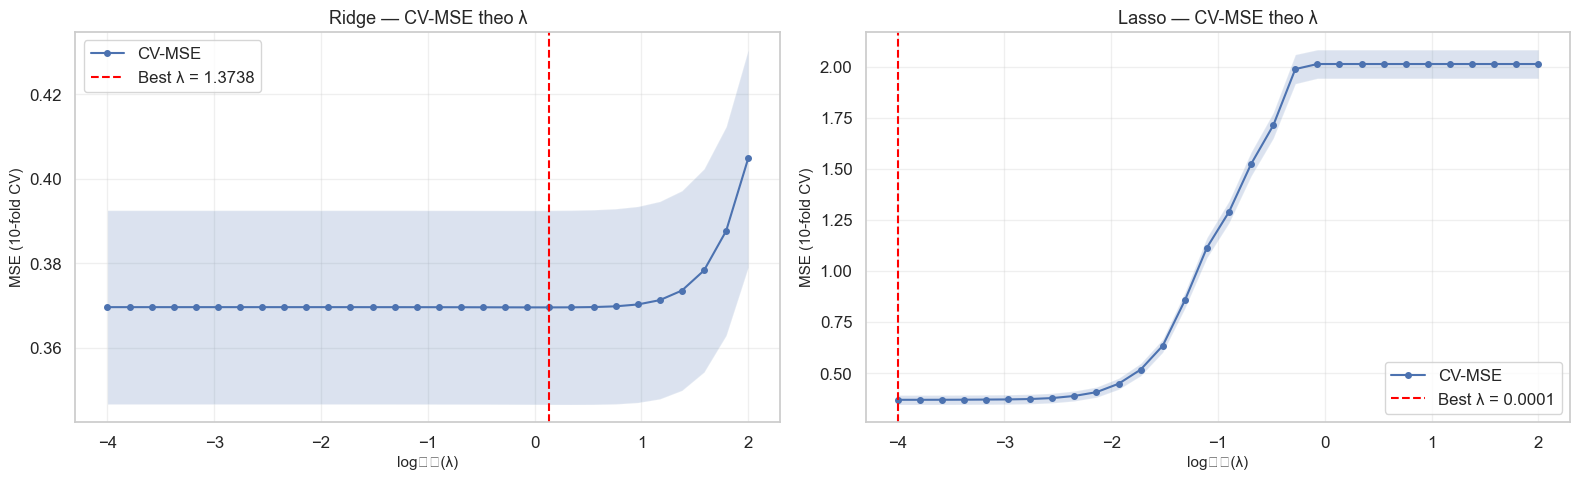

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cv_result, name in zip(axes, [ridge_cv, lasso_cv], ["Ridge", "Lasso"]):
    log_lams = np.log10(cv_result["lambdas"])
    means = np.array(cv_result["all_mses"])
    stds = np.array(cv_result["all_stds"])
    
    ax.plot(log_lams, means, "o-", markersize=4, label="CV-MSE")
    ax.fill_between(log_lams, means - stds, means + stds, alpha=0.2)
    ax.axvline(x=np.log10(cv_result["best_lambda"]), color="red",
               linestyle="--", label=f"Best λ = {cv_result['best_lambda']:.4f}")
    ax.set_xlabel("log₁₀(λ)")
    ax.set_ylabel("MSE (10-fold CV)")
    ax.set_title(f"{name} — CV-MSE theo λ")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5. Huấn luyện lại với λ tối ưu

In [12]:
# Ridge với lambda tối ưu
ridge_best = RidgeRegression(lam=ridge_cv["best_lambda"])
ridge_best.fit(X_train, y_train)
y_pred_ridge_best = ridge_best.predict(X_test)
metrics_ridge_best = compute_all_metrics(y_test, y_pred_ridge_best)
print_metrics(metrics_ridge_best, f"Ridge (λ={ridge_cv['best_lambda']:.4f}) — Test")

# Lasso với lambda tối ưu
lasso_best = LassoRegression(lam=lasso_cv["best_lambda"], max_iter=2000)
lasso_best.fit(X_train, y_train)
y_pred_lasso_best = lasso_best.predict(X_test)
metrics_lasso_best = compute_all_metrics(y_test, y_pred_lasso_best)
print_metrics(metrics_lasso_best, f"Lasso (λ={lasso_cv['best_lambda']:.4f}) — Test")
print(f"Lasso — hệ số khác 0: {lasso_best.n_nonzero_coefs} / {len(lasso_best.coefficients)}")


  Ridge (λ=1.3738) — Test
     MSE: 0.348625
    RMSE: 0.590445
     MAE: 0.447191
      R²: 0.825475


  Lasso (λ=0.0001) — Test
     MSE: 0.348553
    RMSE: 0.590384
     MAE: 0.447180
      R²: 0.825511

Lasso — hệ số khác 0: 48 / 49


### 4.6. Phân tích kết quả chọn λ

Biểu đồ CV-MSE cho thấy:
- **Ridge**: MSE ổn định ở vùng $\lambda$ nhỏ và tăng dần khi $\lambda$ lớn (underfitting). $\lambda$ tối ưu thường nằm ở vùng trung bình.
- **Lasso**: Tương tự nhưng nhạy hơn với $\lambda$ lớn do phạt L1 mạnh hơn (triệt tiêu hệ số hoàn toàn).

So sánh với kết quả $\lambda = 1.0$ ban đầu, mô hình sau khi tune $\lambda$ thường đạt MSE thấp hơn, xác nhận tầm quan trọng của việc chọn siêu tham số bằng CV.

---
## 5. Regularization Path

### 5.1. Cơ sở lý thuyết

**Regularization path** biểu diễn giá trị hệ số $w_j$ như hàm của $\log\lambda$:
- Khi $\lambda$ nhỏ: hệ số gần với OLS
- Khi $\lambda$ tăng: hệ số bị co dần về 0

**Ridge path**: Hệ số co liên tục, tiệm cận 0 nhưng không bao giờ bằng 0.

**Lasso path** (warm start): Sử dụng nghiệm của $\lambda$ lớn làm initialization cho $\lambda$ nhỏ hơn → hội tụ nhanh. Hệ số lần lượt bị triệt tiêu thành 0 khi $\lambda$ tăng.

### 5.2. Cài đặt hàm tính path

In [13]:
def compute_ridge_path(X, y, lambdas):
    """Tính Ridge coefficient path."""
    coefs = []
    for lam in lambdas:
        model = RidgeRegression(lam=lam)
        model.fit(X, y)
        coefs.append(model.coefficients.copy())
    return np.array(coefs)

def compute_lasso_path(X, y, lambdas, max_iter=2000, tol=1e-6):
    """Tính Lasso coefficient path với warm start.
    
    Lambdas được sắp xếp giảm dần để tận dụng warm start.
    """
    sorted_idx = np.argsort(-lambdas)
    lambdas_sorted = lambdas[sorted_idx]
    
    coefs = np.zeros((len(lambdas), X.shape[1]))
    current_w = None
    
    for i, lam in enumerate(lambdas_sorted):
        model = LassoRegression(lam=lam, max_iter=max_iter, tol=tol)
        model.fit(X, y, warm_start_w=current_w)
        original_idx = sorted_idx[i]
        coefs[original_idx] = model.coefficients.copy()
        current_w = model.w.copy()
    
    return coefs

### 5.3. Vẽ Regularization Path

Tính Ridge path...
Tính Lasso path (warm start)...
Xong!


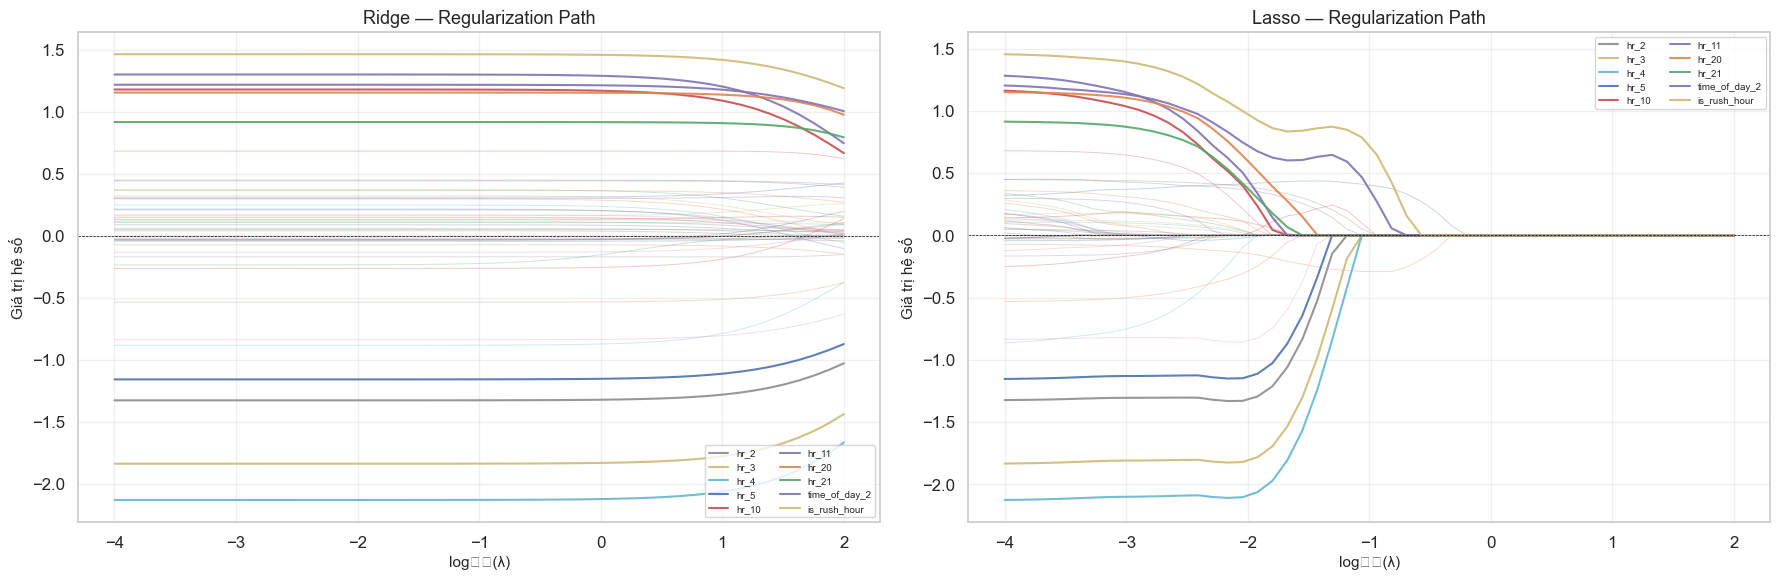

In [14]:
path_lambdas = np.logspace(-4, 2, 50)

# Tính paths
print("Tính Ridge path...")
ridge_coefs = compute_ridge_path(X_train, y_train, path_lambdas)
print("Tính Lasso path (warm start)...")
lasso_coefs = compute_lasso_path(X_train, y_train, path_lambdas)
print("Xong!")

# Vẽ
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
log_lams = np.log10(path_lambdas)

for ax, coefs, name in zip(axes, [ridge_coefs, lasso_coefs], ["Ridge", "Lasso"]):
    # Top-k features
    last_coef = np.abs(coefs[0])
    top_k = 10
    top_indices = np.argsort(last_coef)[-top_k:]
    
    for j in range(coefs.shape[1]):
        lw, alpha, label = 0.7, 0.3, None
        if j in top_indices:
            label = feature_names[j] if j < len(feature_names) else f"f{j}"
            lw, alpha = 1.5, 0.9
        ax.plot(log_lams, coefs[:, j], linewidth=lw, alpha=alpha, label=label)
    
    ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
    ax.set_xlabel("log₁₀(λ)")
    ax.set_ylabel("Giá trị hệ số")
    ax.set_title(f"{name} — Regularization Path")
    ax.legend(fontsize=7, loc="best", ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4. Phân tích Regularization Path

Quan sát hai đồ thị:

- **Ridge path**: Tất cả hệ số co dần đều về 0 khi $\lambda$ tăng — không có hệ số nào bị triệt tiêu hoàn toàn. Các đặc trưng quan trọng nhất (hệ số lớn ở $\lambda$ nhỏ) vẫn giữ giá trị tương đối lớn hơn.

- **Lasso path**: Hệ số lần lượt bị đặt bằng 0 khi $\lambda$ tăng. Các đặc trưng ít quan trọng bị "loại khỏi" mô hình trước, chỉ những đặc trưng then chốt tồn tại ở $\lambda$ lớn. Đây chính là cơ chế **feature selection** tự động của Lasso.

---
## 6. Phân tích vùng tối ưu $(\lambda_1, \lambda_2)$ cho Elastic Net

### 6.1. Cơ sở lý thuyết

Elastic Net có hai siêu tham số $(\lambda_1, \lambda_2)$. Ta cần tìm cặp tối ưu bằng **grid search 2D** kết hợp cross-validation.

Vùng tối ưu được hiển thị dưới dạng **heatmap** của CV-MSE.

In [15]:
# Grid 2D cho Elastic Net
lam1_grid = np.logspace(-4, 0, 8)
lam2_grid = np.logspace(-4, 0, 8)

print("Tìm kiếm vùng tối ưu (λ1, λ2) cho Elastic Net...")
folds = k_fold_split(len(X_train), k=5, seed=SEED)  # k=5 để nhanh hơn
enet_mse_grid = np.zeros((len(lam2_grid), len(lam1_grid)))

for i, l2 in enumerate(lam2_grid):
    for j, l1 in enumerate(lam1_grid):
        fold_mses = []
        for train_idx, val_idx in folds:
            model = ElasticNetRegression(lam1=l1, lam2=l2, max_iter=1000)
            model.fit(X_train[train_idx], y_train[train_idx])
            pred = model.predict(X_train[val_idx])
            fold_mses.append(mse(y_train[val_idx], pred))
        enet_mse_grid[i, j] = np.mean(fold_mses)

# Tìm best
best_pos = np.unravel_index(np.argmin(enet_mse_grid), enet_mse_grid.shape)
best_lam2 = lam2_grid[best_pos[0]]
best_lam1 = lam1_grid[best_pos[1]]
print(f"Best (λ1, λ2) = ({best_lam1:.6f}, {best_lam2:.6f})")
print(f"Best CV-MSE = {enet_mse_grid[best_pos]:.6f}")

Tìm kiếm vùng tối ưu (λ1, λ2) cho Elastic Net...
Best (λ1, λ2) = (0.000100, 0.000100)
Best CV-MSE = 0.369309


### 6.2. Heatmap vùng tối ưu

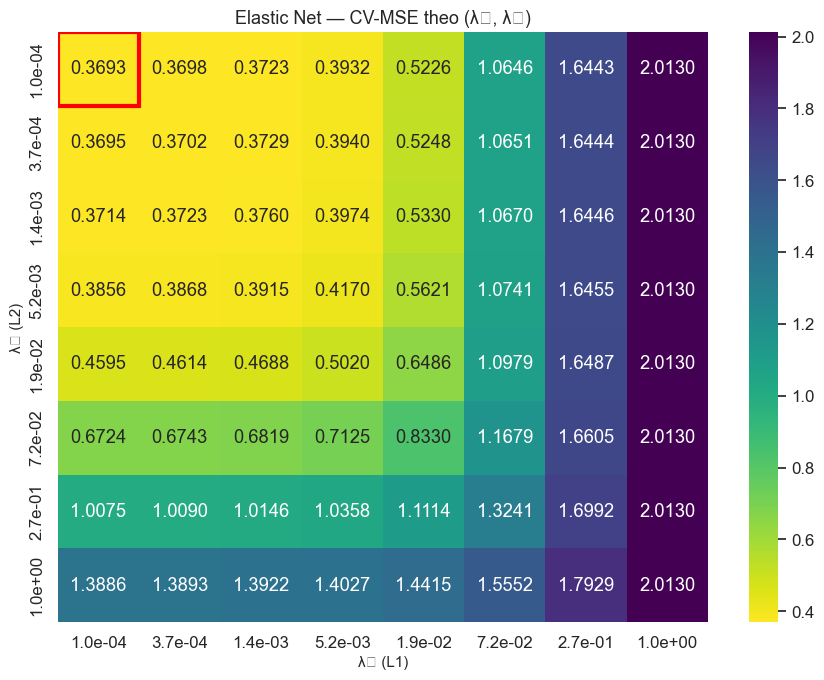

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
lam1_labels = [f"{v:.1e}" for v in lam1_grid]
lam2_labels = [f"{v:.1e}" for v in lam2_grid]

sns.heatmap(enet_mse_grid, annot=True, fmt=".4f", cmap="viridis_r",
            xticklabels=lam1_labels, yticklabels=lam2_labels, ax=ax)
ax.set_xlabel("λ₁ (L1)")
ax.set_ylabel("λ₂ (L2)")
ax.set_title("Elastic Net — CV-MSE theo (λ₁, λ₂)")

# Đánh dấu best
ax.add_patch(plt.Rectangle((best_pos[1], best_pos[0]), 1, 1,
             fill=False, edgecolor="red", linewidth=3))
plt.tight_layout()
plt.show()

### 6.3. Huấn luyện Elastic Net tối ưu

In [17]:
enet_best = ElasticNetRegression(lam1=best_lam1, lam2=best_lam2, max_iter=2000)
enet_best.fit(X_train, y_train)

y_pred_enet_best = enet_best.predict(X_test)
metrics_enet_best = compute_all_metrics(y_test, y_pred_enet_best)
print_metrics(metrics_enet_best, f"Elastic Net (λ1={best_lam1:.4f}, λ2={best_lam2:.4f}) — Test")
n_nz = int(np.sum(np.abs(enet_best.coefficients) > 1e-10))
print(f"Hệ số khác 0: {n_nz} / {len(enet_best.coefficients)}")


  Elastic Net (λ1=0.0001, λ2=0.0001) — Test
     MSE: 0.348589
    RMSE: 0.590414
     MAE: 0.447255
      R²: 0.825494

Hệ số khác 0: 48 / 49


### 6.4. Phân tích kết quả Elastic Net

Heatmap cho thấy vùng $(\lambda_1, \lambda_2)$ cho MSE thấp nhất. Thông thường:
- Vùng tối ưu nằm ở $\lambda_1, \lambda_2$ nhỏ (gần OLS nhưng vừa đủ regularization)
- $\lambda_1$ lớn → sparse hơn (nhiều hệ số = 0)
- $\lambda_2$ lớn → shrinkage mạnh hơn (hệ số nhỏ đều)

Elastic Net thường cho kết quả tốt hơn Lasso đơn thuần khi có nhiều feature tương quan.

---
## 7. Lựa chọn Đặc trưng (Feature Selection)

### 7.1. Cơ sở lý thuyết

Ba phương pháp feature selection:

**a) Forward Stepwise Selection**
- Bắt đầu với tập rỗng
- Mỗi bước: thêm feature giảm validation MSE nhiều nhất
- Dừng khi thêm feature không cải thiện hoặc đạt số feature tối đa
- Độ phức tạp: $O(D^2)$ lần fit model

**b) Backward Elimination**
- Bắt đầu với tất cả features
- Mỗi bước: loại bỏ feature mà khi bỏ MSE tăng ít nhất
- Dừng khi chỉ còn `min_features`
- Độ phức tạp: $O(D^2)$ lần fit model

**c) Lasso-based Selection**
- Huấn luyện Lasso với $\lambda$ phù hợp
- Chọn các feature có $|w_j| > \text{threshold}$
- Nhanh nhất, chỉ cần 1 lần fit

### 7.2. Cài đặt Normal Equations (helper cho Feature Selection)

In [18]:
class NormalEquationLR:
    """OLS via Normal Equations — dùng làm base model cho feature selection."""
    def __init__(self):
        self.w = None
    
    def fit(self, X, y, **kwargs):
        X_b = _add_bias(X)
        XtX = X_b.T @ X_b
        Xty = X_b.T @ y
        self.w = np.linalg.solve(XtX, Xty)
        return self
    
    def predict(self, X):
        return _add_bias(X) @ self.w

### 7.3. Cài đặt các hàm Feature Selection

In [19]:
def forward_stepwise_selection(X, y, X_val, y_val, max_features=None, verbose=True):
    """Forward Stepwise: mỗi bước thêm feature giảm val MSE nhiều nhất."""
    n_features = X.shape[1]
    if max_features is None:
        max_features = n_features
    
    selected = []
    remaining = list(range(n_features))
    val_mses = []
    feature_order = []
    best_overall_mse = float("inf")
    best_overall_selected = []
    
    for step in range(min(max_features, n_features)):
        best_mse = float("inf")
        best_feature = -1
        
        for f in remaining:
            current = selected + [f]
            model = NormalEquationLR()
            model.fit(X[:, current], y)
            score = mse(y_val, model.predict(X_val[:, current]))
            if score < best_mse:
                best_mse = score
                best_feature = f
        
        selected.append(best_feature)
        remaining.remove(best_feature)
        val_mses.append(best_mse)
        feature_order.append(best_feature)
        
        if best_mse < best_overall_mse:
            best_overall_mse = best_mse
            best_overall_selected = selected.copy()
        
        if verbose:
            fname = feature_names[best_feature] if best_feature < len(feature_names) else f"f{best_feature}"
            print(f"  Step {step+1:3d} | + {fname:20s} | Val MSE: {best_mse:.6f}")
    
    return {"selected_features": best_overall_selected, "val_mses": val_mses,
            "feature_order": feature_order, "best_val_mse": best_overall_mse}


def backward_elimination(X, y, X_val, y_val, min_features=1, verbose=True):
    """Backward Elimination: mỗi bước loại feature ít ảnh hưởng nhất."""
    n_features = X.shape[1]
    current_features = list(range(n_features))
    val_mses = []
    removal_order = []
    
    model = NormalEquationLR()
    model.fit(X[:, current_features], y)
    initial_mse = mse(y_val, model.predict(X_val[:, current_features]))
    val_mses.append(initial_mse)
    best_overall_mse = initial_mse
    best_overall_selected = current_features.copy()
    
    if verbose:
        print(f"  Start   | {n_features} features | Val MSE: {initial_mse:.6f}")
    
    while len(current_features) > min_features:
        best_mse = float("inf")
        worst_feature = -1
        
        for f in current_features:
            reduced = [c for c in current_features if c != f]
            model = NormalEquationLR()
            model.fit(X[:, reduced], y)
            score = mse(y_val, model.predict(X_val[:, reduced]))
            if score < best_mse:
                best_mse = score
                worst_feature = f
        
        current_features.remove(worst_feature)
        removal_order.append(worst_feature)
        val_mses.append(best_mse)
        
        if best_mse < best_overall_mse:
            best_overall_mse = best_mse
            best_overall_selected = current_features.copy()
        
        if verbose:
            fname = feature_names[worst_feature] if worst_feature < len(feature_names) else f"f{worst_feature}"
            print(f"  Step {len(removal_order):3d} | - {fname:20s} "
                  f"| {len(current_features)} left | Val MSE: {best_mse:.6f}")
    
    return {"selected_features": best_overall_selected, "val_mses": val_mses,
            "removal_order": removal_order, "best_val_mse": best_overall_mse}


def lasso_feature_selection(X, y, lam, threshold=1e-10, verbose=True):
    """Feature selection dựa trên hệ số khác 0 của Lasso."""
    model = LassoRegression(lam=lam, max_iter=2000)
    model.fit(X, y)
    coefs = model.coefficients
    selected = [i for i in range(len(coefs)) if abs(coefs[i]) > threshold]
    
    if verbose:
        print(f"\n  Lasso Feature Selection (λ = {lam})")
        print(f"  Hệ số khác 0: {len(selected)} / {len(coefs)}")
        if len(selected) <= 20:
            for idx in selected:
                fname = feature_names[idx] if idx < len(feature_names) else f"f{idx}"
                print(f"    {fname:20s}: {coefs[idx]:+.6f}")
    
    return {"selected_features": selected, "coefficients": coefs, "n_selected": len(selected)}

### 7.4. Chạy Forward Stepwise Selection

In [20]:
print("=== Forward Stepwise Selection ===")
fwd_result = forward_stepwise_selection(X_train, y_train, X_val, y_val, verbose=True)
print(f"\nBest subset: {len(fwd_result['selected_features'])} features")
print(f"Best Val MSE: {fwd_result['best_val_mse']:.6f}")

=== Forward Stepwise Selection ===
  Step   1 | + is_rush_hour         | Val MSE: 1.669216
  Step   2 | + time_of_day_2        | Val MSE: 1.345530
  Step   3 | + temp                 | Val MSE: 1.142627
  Step   4 | + hr_4                 | Val MSE: 0.964654
  Step   5 | + hr_3                 | Val MSE: 0.832974
  Step   6 | + hr_2                 | Val MSE: 0.725682
  Step   7 | + hr_5                 | Val MSE: 0.639498
  Step   8 | + hr_1                 | Val MSE: 0.546664
  Step   9 | + yr                   | Val MSE: 0.486404
  Step  10 | + weathersit_3         | Val MSE: 0.452456
  Step  11 | + hr_20                | Val MSE: 0.436674
  Step  12 | + season_4             | Val MSE: 0.422156
  Step  13 | + hum                  | Val MSE: 0.411636
  Step  14 | + hr_10                | Val MSE: 0.403169
  Step  15 | + hr_21                | Val MSE: 0.392014
  Step  16 | + hr_11                | Val MSE: 0.378850
  Step  17 | + hr_17                | Val MSE: 0.367163
  Step  18 | 

### 7.5. Chạy Backward Elimination

In [21]:
print("=== Backward Elimination ===")
bwd_result = backward_elimination(X_train, y_train, X_val, y_val, verbose=True)
print(f"\nBest subset: {len(bwd_result['selected_features'])} features")
print(f"Best Val MSE: {bwd_result['best_val_mse']:.6f}")

=== Backward Elimination ===
  Start   | 49 features | Val MSE: 0.336403
  Step   1 | - time_of_day_1        | 48 left | Val MSE: 0.335379
  Step   2 | - weekday_6            | 47 left | Val MSE: 0.334921
  Step   3 | - season_2             | 46 left | Val MSE: 0.334471
  Step   4 | - hr_14                | 45 left | Val MSE: 0.334109
  Step   5 | - weathersit_2         | 44 left | Val MSE: 0.333839
  Step   6 | - hr_8                 | 43 left | Val MSE: 0.333667
  Step   7 | - mnth_2               | 42 left | Val MSE: 0.333413
  Step   8 | - mnth_12              | 41 left | Val MSE: 0.333226
  Step   9 | - mnth_10              | 40 left | Val MSE: 0.332827
  Step  10 | - windspeed            | 39 left | Val MSE: 0.332702
  Step  11 | - hr_15                | 38 left | Val MSE: 0.332608
  Step  12 | - weekday_2            | 37 left | Val MSE: 0.332542
  Step  13 | - weathersit_4         | 36 left | Val MSE: 0.332549
  Step  14 | - mnth_11              | 35 left | Val MSE: 0.332555
  S

### 7.6. Chạy Lasso Feature Selection

In [22]:
print("=== Lasso Feature Selection ===")
lasso_fs = lasso_feature_selection(X_train, y_train, lam=lasso_cv["best_lambda"])

=== Lasso Feature Selection ===

  Lasso Feature Selection (λ = 0.0001)
  Hệ số khác 0: 48 / 49


### 7.7. So sánh 3 phương pháp Feature Selection

In [23]:
# Đánh giá trên test set với từng tập features
methods = {
    "Forward Stepwise": fwd_result["selected_features"],
    "Backward Elim.": bwd_result["selected_features"],
    "Lasso-based": lasso_fs["selected_features"],
    "All Features": list(range(X_train.shape[1])),
}

print("\n" + "="*70)
print("  SO SÁNH FEATURE SELECTION — Test Set")
print("="*70)
fs_results = []
for name, features in methods.items():
    model = NormalEquationLR()
    model.fit(X_train[:, features], y_train)
    y_pred = model.predict(X_test[:, features])
    m = compute_all_metrics(y_test, y_pred)
    fs_results.append({"Method": name, "# Features": len(features), **m})
    print(f"  {name:20s} | {len(features):2d} features | MSE={m['MSE']:.6f} | R²={m['R²']:.6f}")
print("="*70)

fs_df = pd.DataFrame(fs_results)


  SO SÁNH FEATURE SELECTION — Test Set
  Forward Stepwise     | 37 features | MSE=0.355798 | R²=0.821885
  Backward Elim.       | 37 features | MSE=0.357176 | R²=0.821195
  Lasso-based          | 48 features | MSE=0.348584 | R²=0.825496
  All Features         | 49 features | MSE=0.348676 | R²=0.825450


### 7.8. Biểu đồ Val MSE theo số đặc trưng

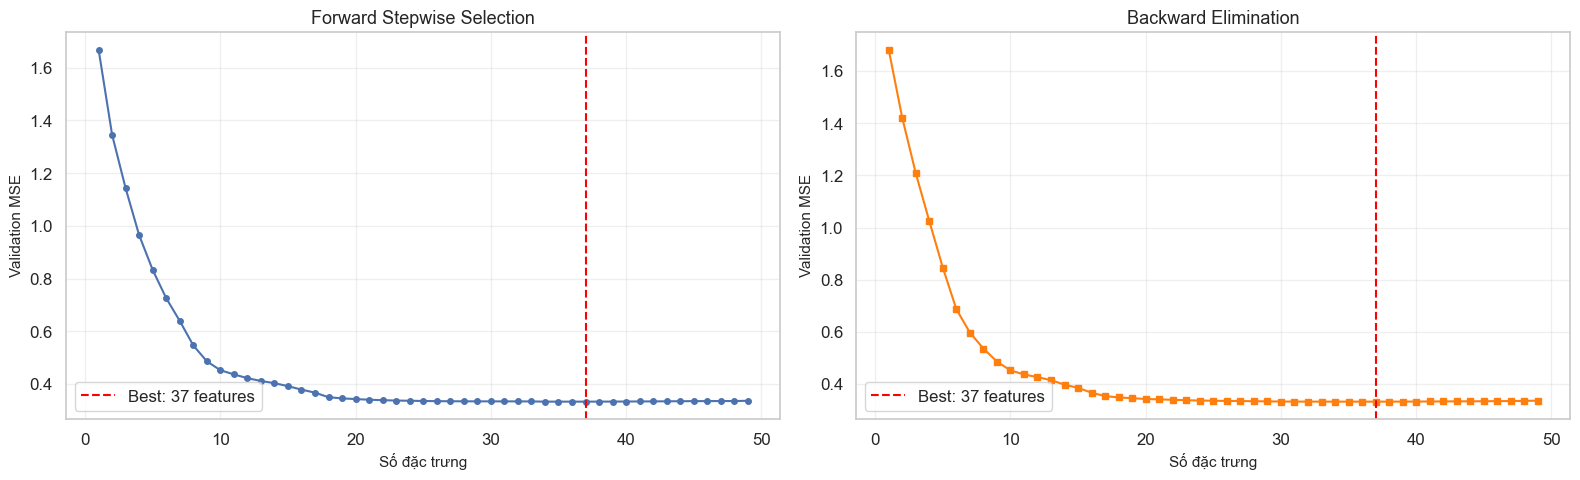

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Forward
axes[0].plot(range(1, len(fwd_result["val_mses"]) + 1), fwd_result["val_mses"], "o-", markersize=4)
best_n_fwd = len(fwd_result["selected_features"])
axes[0].axvline(x=best_n_fwd, color="red", linestyle="--", label=f"Best: {best_n_fwd} features")
axes[0].set_xlabel("Số đặc trưng")
axes[0].set_ylabel("Validation MSE")
axes[0].set_title("Forward Stepwise Selection")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Backward
n_total = X_train.shape[1]
n_features_bwd = list(range(n_total, 0, -1))
axes[1].plot(n_features_bwd, bwd_result["val_mses"], "s-", markersize=4, color="tab:orange")
best_n_bwd = len(bwd_result["selected_features"])
axes[1].axvline(x=best_n_bwd, color="red", linestyle="--", label=f"Best: {best_n_bwd} features")
axes[1].set_xlabel("Số đặc trưng")
axes[1].set_ylabel("Validation MSE")
axes[1].set_title("Backward Elimination")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.9. Phân tích kết quả Feature Selection

Ba phương pháp feature selection cho kết quả khác nhau:

- **Forward Stepwise**: Xây dựng tập features dần dần, có xu hướng chọn đúng các features quan trọng nhất trước. Tuy nhiên, một khi feature đã được thêm vào thì không thể loại bỏ (greedy).

- **Backward Elimination**: Bắt đầu từ tất cả, loại bỏ feature dư thừa. Thường tìm được tập features tốt hơn Forward khi có nhiều feature tương quan (vì xét trong ngữ cảnh đầy đủ).

- **Lasso-based**: Nhanh nhất, chỉ một lần fit. Tập features phụ thuộc vào $\lambda$ — với $\lambda$ tối ưu từ CV, thường cho kết quả tốt và tương đương các phương pháp wrapper.

Biểu đồ MSE theo số features cho thấy: thêm quá nhiều feature không cải thiện (overfitting), loại bỏ quá nhiều thì underfitting → tồn tại một **số features tối ưu**.

---
## 8. Bảng tổng hợp kết quả Section 1.2

In [25]:
all_models_sec12 = {
    "Ridge (λ=1.0)": metrics_ridge,
    f"Ridge (λ={ridge_cv['best_lambda']:.4f}, CV)": metrics_ridge_best,
    "Lasso (λ=0.01)": metrics_lasso,
    f"Lasso (λ={lasso_cv['best_lambda']:.4f}, CV)": metrics_lasso_best,
    "Elastic Net (default)": metrics_enet,
    f"Elastic Net (λ1={best_lam1:.4f}, λ2={best_lam2:.4f}, CV)": metrics_enet_best,
}

results_data = []
for name, metrics in all_models_sec12.items():
    results_data.append({"Model": name, **metrics})

results_df = pd.DataFrame(results_data)
print("\n" + "="*85)
print("  BẢNG TỔNG HỢP — Regularization & Feature Selection (Section 1.2)")
print("="*85)
print(results_df.to_string(index=False, float_format="%.6f"))
print("="*85)

results_section_1_2 = results_df.copy()
print("\n✓ Kết quả đã lưu vào biến `results_section_1_2`")


  BẢNG TỔNG HỢP — Regularization & Feature Selection (Section 1.2)
                                 Model      MSE     RMSE      MAE       R²
                         Ridge (λ=1.0) 0.348631 0.590450 0.447178 0.825473
                  Ridge (λ=1.3738, CV) 0.348625 0.590445 0.447191 0.825475
                        Lasso (λ=0.01) 0.413482 0.643026 0.497357 0.793008
                  Lasso (λ=0.0001, CV) 0.348553 0.590384 0.447180 0.825511
                 Elastic Net (default) 0.396236 0.629473 0.487076 0.801641
Elastic Net (λ1=0.0001, λ2=0.0001, CV) 0.348589 0.590414 0.447255 0.825494

✓ Kết quả đã lưu vào biến `results_section_1_2`


## 9. Kết luận Section 1.2

**Regularization**:
- Ridge, Lasso và Elastic Net có hiệu năng tương đương hoặc tốt hơn OLS khi chọn $\lambda$ phù hợp bằng CV
- Ridge ổn định nhưng không loại bỏ features; Lasso thực hiện feature selection tự động; Elastic Net là giải pháp lai tốt nhất

**Feature Selection**:
- Cả 3 phương pháp (Forward, Backward, Lasso-based) đều chỉ ra rằng không phải tất cả features đều cần thiết
- Mô hình sử dụng tập features được chọn lọc có thể đạt hiệu năng tương đương với ít features hơn → cải thiện interpretability và giảm overfitting

In [26]:
# SAVE RESULTS FOR EVALUATION NOTEBOOK

import joblib
from pathlib import Path


def _resolve_results_dir():
    candidates = [
        Path.cwd() / "code" / "Part1_Regression" / "results",
        Path.cwd() / "results",
        Path.cwd().parent / "results",
        Path.cwd().parent / "Part1_Regression" / "results",
    ]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
    fallback = candidates[0]
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback.resolve()


def _require(obj, name):
    if obj is None:
        raise NameError(f"Missing required object for export: {name}")
    return obj


def _metrics_for_export(y_true, y_pred):
    metrics = compute_all_metrics(y_true, y_pred)
    return {
        "MSE": float(metrics["MSE"]),
        "RMSE": float(metrics["RMSE"]),
        "MAE": float(metrics["MAE"]),
        "R2": float(metrics.get("R2", metrics.get("R²"))),
    }


RESULTS_DIR = _resolve_results_dir()

ridge_export = _require(globals().get("ridge_best", globals().get("ridge_model")), "ridge_best/ridge_model")
lasso_export = _require(globals().get("lasso_best", globals().get("lasso_model")), "lasso_best/lasso_model")
enet_export = _require(globals().get("enet_best", globals().get("enet_model")), "enet_best/enet_model")

predictions_04 = {
    "Ridge": {
        "y_pred_val": ridge_export.predict(X_val),
        "y_pred_test": ridge_export.predict(X_test),
    },
    "Lasso": {
        "y_pred_val": lasso_export.predict(X_val),
        "y_pred_test": lasso_export.predict(X_test),
    },
    "ElasticNet": {
        "y_pred_val": enet_export.predict(X_val),
        "y_pred_test": enet_export.predict(X_test),
    },
}

metrics_04 = {
    name: _metrics_for_export(y_test, preds["y_pred_test"])
    for name, preds in predictions_04.items()
}

trained_models_04 = {
    "Ridge": ridge_export,
    "Lasso": lasso_export,
    "ElasticNet": enet_export,
}

best_params_04 = {
    "Ridge": {
        "lam": float(ridge_cv["best_lambda"]) if "ridge_cv" in globals() else float(getattr(ridge_export, "lam", float("nan"))),
    },
    "Lasso": {
        "lam": float(lasso_cv["best_lambda"]) if "lasso_cv" in globals() else float(getattr(lasso_export, "lam", float("nan"))),
    },
    "ElasticNet": {
        "lam1": float(best_lam1) if "best_lam1" in globals() else float(getattr(enet_export, "lam1", float("nan"))),
        "lam2": float(best_lam2) if "best_lam2" in globals() else float(getattr(enet_export, "lam2", float("nan"))),
    },
}

joblib.dump(metrics_04, RESULTS_DIR / "metrics_04_regularized_regression.joblib")
joblib.dump(predictions_04, RESULTS_DIR / "predictions_04_regularized_regression.joblib")
joblib.dump(trained_models_04, RESULTS_DIR / "trained_models_04.joblib")
joblib.dump(best_params_04, RESULTS_DIR / "best_params_04.joblib")

print(f"Saved 04 results to {RESULTS_DIR}")
print(sorted(p.name for p in RESULTS_DIR.glob("*04*")))



Saved 04 results to D:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\code\Part1_Regression\models\results
['best_params_04.joblib', 'metrics_04_regularized_regression.joblib', 'predictions_04_regularized_regression.joblib', 'trained_models_04.joblib']
